# 05 - K-Means Customer Segmentation

Finding natural customer groups using machine learning

## Step 1: Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print(' All libraries imported!')

 All libraries imported!


## Step 2: Load RFM Features

In [37]:
# Load the RFM data we created earlier
rfm = pd.read_csv('rfm_features.csv', index_col='CustomerID')

print('RFM Data Loaded!')
print(f'Shape: {rfm.shape}')
print(f'\nFirst 5 rows:')
print(rfm.head())
print(f'\nData types:')
print(rfm.dtypes)

RFM Data Loaded!
Shape: (4338, 7)

First 5 rows:
            Recency  Frequency  Monetary           AOV       CLV  \
CustomerID                                                         
12346.0         326          1  77183.60  77183.600000  77183.60   
12347.0           2          7   4310.00    615.714286   4310.00   
12348.0          75          4   1797.24    449.310000   1797.24   
12349.0          19          1   1757.55   1757.550000   1757.55   
12350.0         310          1    334.40    334.400000    334.40   

            Days_as_Customer  Purchase_Rate  
CustomerID                                   
12346.0                    0       1.000000  
12347.0                  365       0.019126  
12348.0                  282       0.014134  
12349.0                    0       1.000000  
12350.0                    0       1.000000  

Data types:
Recency               int64
Frequency             int64
Monetary            float64
AOV                 float64
CLV                 float64

## Step 3: Normalize (Scale) the Data

WHY? All features need to be on the same scale (0-1)

In [38]:
print('BEFORE Normalization:')
print('='*60)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print('\n\nNotice the HUGE DIFFERENCES in scale:')
print(f'  Recency ranges: 1 to {rfm["Recency"].max()} days')
print(f'  Frequency ranges: 1 to {rfm["Frequency"].max()} purchases')
print(f'  Monetary ranges: £{rfm["Monetary"].min():.2f} to £{rfm["Monetary"].max():.2f}')
print('\nMonetary is MUCH BIGGER! K-Means will think it\'s most important!')
print('fix this by normalizing')

BEFORE Normalization:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


Notice the HUGE DIFFERENCES in scale:
  Recency ranges: 1 to 374 days
  Frequency ranges: 1 to 209 purchases
  Monetary ranges: £3.75 to £280206.02

Monetary is MUCH BIGGER! K-Means will think it's most important!
fix this by normalizing


In [39]:
# Step 1: Create a scaler object
scaler = StandardScaler()

# Step 2: Select only the features we want to normalize
features_to_scale = rfm[['Recency', 'Frequency', 'Monetary']]

# Step 3: Fit and transform (normalize) the data
rfm_scaled = scaler.fit_transform(features_to_scale)

# Step 4: Convert back to DataFrame for easier viewing
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

print('AFTER Normalization:')
print('='*60)
print(rfm_scaled_df.describe())
print('\n\nNow all features are on the SAME SCALE (-3 to +3)!')
print('Each feature is treated FAIRLY by K-Means!')

AFTER Normalization:
            Recency     Frequency      Monetary
count  4.338000e+03  4.338000e+03  4.338000e+03
mean   2.702618e-17  1.801745e-17  1.965540e-17
std    1.000115e+00  1.000115e+00  1.000115e+00
min   -9.153401e-01 -4.250965e-01 -2.276151e-01
25%   -7.453445e-01 -4.250965e-01 -1.939190e-01
50%   -4.153533e-01 -2.951776e-01 -1.536162e-01
75%    4.946227e-01  9.457903e-02 -4.319704e-02
max    2.814561e+00  2.659803e+01  3.096074e+01


Now all features are on the SAME SCALE (-3 to +3)!
Each feature is treated FAIRLY by K-Means!


In [40]:
print('\nBEFORE vs AFTER (First 10 customers):')
print('='*80)

comparison = pd.DataFrame({
    'Recency_Before': rfm['Recency'].head(10),
    'Recency_After': rfm_scaled_df['Recency'].head(10),
    'Frequency_Before': rfm['Frequency'].head(10),
    'Frequency_After': rfm_scaled_df['Frequency'].head(10),
    'Monetary_Before': rfm['Monetary'].head(10),
    'Monetary_After': rfm_scaled_df['Monetary'].head(10)
})

print(comparison)


BEFORE vs AFTER (First 10 customers):
            Recency_Before  Recency_After  Frequency_Before  Frequency_After  \
CustomerID                                                                     
12346.0                326       2.334574                 1        -0.425097   
12347.0                  2      -0.905340                 7         0.354417   
12348.0                 75      -0.175360                 4        -0.035340   
12349.0                 19      -0.735345                 1        -0.425097   
12350.0                310       2.174578                 1        -0.425097   
12352.0                 36      -0.565349                 8         0.484336   
12353.0                204       1.114606                 1        -0.425097   
12354.0                232       1.394599                 1        -0.425097   
12355.0                214       1.214604                 1        -0.425097   
12356.0                 23      -0.695346                 3        -0.165259   



## Step 4: Choose K (Number of Clusters)

Use the Elbow Method to find the best K

In [41]:
print('ELBOW METHOD EXPLANATION:')
print('='*60)
print('\nWe\'ll test K = 2, 3, 4, 5, 6, 7, 8, 9, 10')
print('For each K, we measure: How tight are the clusters?')
print('\nInertia = Sum of distances from each customer to their cluster center')
print('Lower inertia = Tighter clusters = Better grouping')
print('\nBUT: Adding more K always reduces inertia!')
print('K=10 will always be better than K=2')
print('\nSolution: Find the "ELBOW" - where benefit stops increasing')

ELBOW METHOD EXPLANATION:

We'll test K = 2, 3, 4, 5, 6, 7, 8, 9, 10
For each K, we measure: How tight are the clusters?

Inertia = Sum of distances from each customer to their cluster center
Lower inertia = Tighter clusters = Better grouping

BUT: Adding more K always reduces inertia!
K=10 will always be better than K=2

Solution: Find the "ELBOW" - where benefit stops increasing


In [42]:
# Test different K values
inertias = []
silhouette_scores = []
K_range = range(2, 11)  # Test K from 2 to 10

print('Testing different K values...')
print('='*60)

for k in K_range:
    # Create and fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    # Store results
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
    
    print(f'K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={silhouette_scores[-1]:.3f}')

print('\nDone! Now let\'s visualize...')

Testing different K values...
K=2: Inertia=9014.57, Silhouette Score=0.896
K=3: Inertia=5441.32, Silhouette Score=0.594
K=4: Inertia=4096.30, Silhouette Score=0.616
K=5: Inertia=3119.79, Silhouette Score=0.617
K=6: Inertia=2473.79, Silhouette Score=0.598
K=7: Inertia=2023.59, Silhouette Score=0.517
K=8: Inertia=1717.01, Silhouette Score=0.486
K=9: Inertia=1468.79, Silhouette Score=0.478
K=10: Inertia=1281.05, Silhouette Score=0.479

Done! Now let's visualize...


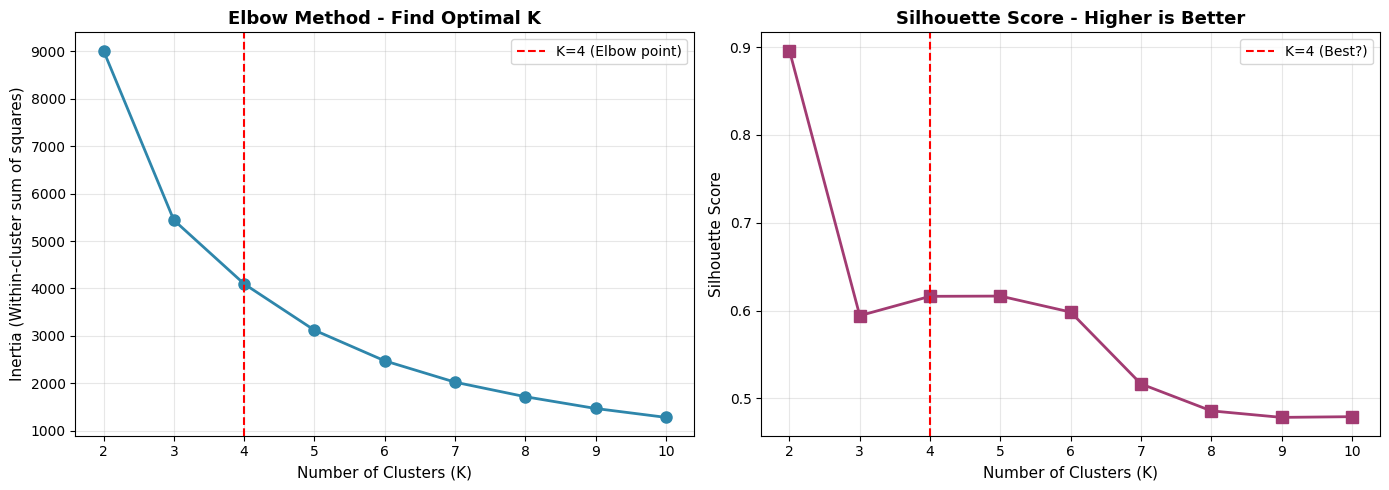

Charts created!

Look for the ELBOW in the first chart (where curve bends)!


In [43]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Inertia (Elbow Method)
axes[0].plot(K_range, inertias, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0].set_title('Elbow Method - Find Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', label='K=4 (Elbow point)')
axes[0].legend()

# Plot 2: Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='#A23B72')
axes[1].set_title('Silhouette Score - Higher is Better', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=4, color='red', linestyle='--', label='K=4 (Best?)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Charts created!')
print('\nLook for the ELBOW in the first chart (where curve bends)!')

In [44]:
print('\nINTERPRETING THE ELBOW CHART:')
print('='*60)
print('\nK=2: Big drop in inertia (good improvement)')
print('K=3: Another drop (still good)')
print('K=4: Another drop (good!) ← ELBOW POINT')
print('K=5: Smaller drop (diminishing returns)')
print('K=6: Even smaller drop (not worth it)')
print('K=7-10: Tiny improvements (not worth complexity)')
print('\nCONCLUSION: K=4 is the sweet spot!')
print('\nWe\'ll have 4 customer segments!')


INTERPRETING THE ELBOW CHART:

K=2: Big drop in inertia (good improvement)
K=3: Another drop (still good)
K=4: Another drop (good!) ← ELBOW POINT
K=5: Smaller drop (diminishing returns)
K=6: Even smaller drop (not worth it)
K=7-10: Tiny improvements (not worth complexity)

CONCLUSION: K=4 is the sweet spot!

We'll have 4 customer segments!


## Step 5: Train Final K-Means Model (K=4)

In [45]:
# Create final K-Means model with K=4
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model
cluster_labels = final_kmeans.fit_predict(rfm_scaled)

# Add cluster labels to original RFM data
rfm['Cluster'] = cluster_labels

print('K-Means model trained!')
print(f'\nCluster assignments:')
print(rfm['Cluster'].value_counts().sort_index())
print(f'\nFirst 10 customers with their clusters:')
print(rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']].head(10))

K-Means model trained!

Cluster assignments:
Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

First 10 customers with their clusters:
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        0
12348.0          75          4   1797.24        0
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1
12352.0          36          8   2506.04        0
12353.0         204          1     89.00        1
12354.0         232          1   1079.40        1
12355.0         214          1    459.40        1
12356.0          23          3   2811.43        0


## Step 6: Analyze Each Cluster

In [46]:
print('CLUSTER ANALYSIS')
print('='*80)

# Get cluster statistics
cluster_stats = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'min', 'max'])

print('\nCluster 0:')
print(rfm[rfm['Cluster']==0][['Recency', 'Frequency', 'Monetary']].describe())

print('\n' + '='*80)
print('\nCluster 1:')
print(rfm[rfm['Cluster']==1][['Recency', 'Frequency', 'Monetary']].describe())

print('\n' + '='*80)
print('\nCluster 2:')
print(rfm[rfm['Cluster']==2][['Recency', 'Frequency', 'Monetary']].describe())

print('\n' + '='*80)
print('\nCluster 3:')
print(rfm[rfm['Cluster']==3][['Recency', 'Frequency', 'Monetary']].describe())

CLUSTER ANALYSIS

Cluster 0:
           Recency    Frequency      Monetary
count  3054.000000  3054.000000   3054.000000
mean     43.702685     3.682711   1353.625312
std      35.966256     2.856518   1540.044490
min       1.000000     1.000000      6.200000
25%      15.000000     1.000000    382.992500
50%      32.000000     3.000000    826.270000
75%      65.000000     5.000000   1783.602500
max     163.000000    15.000000  21429.390000


Cluster 1:
           Recency    Frequency     Monetary
count  1067.000000  1067.000000  1067.000000
mean    248.075914     1.552015   478.848773
std      66.330522     1.070613   637.701862
min     143.000000     1.000000     3.750000
25%     190.000000     1.000000   170.395000
50%     243.000000     1.000000   310.260000
75%     299.000000     2.000000   539.630000
max     374.000000    12.000000  9864.260000


Cluster 2:
         Recency   Frequency       Monetary
count  13.000000   13.000000      13.000000
mean    7.384615   82.538462  127187.9

In [47]:
print('\n\nQUICK CLUSTER SUMMARY:')
print('='*80)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary['Size'] = rfm['Cluster'].value_counts().sort_index()
cluster_summary['Percent'] = (cluster_summary['Size'] / len(rfm) * 100).round(1)

print(cluster_summary.round(2))

print('\n\nCLUSTER INTERPRETATION:')
print('='*80)

for cluster in range(4):
    cluster_data = rfm[rfm['Cluster']==cluster][['Recency', 'Frequency', 'Monetary']].mean()
    size = (rfm['Cluster']==cluster).sum()
    percent = size / len(rfm) * 100
    
    print(f'\nCluster {cluster}: {size} customers ({percent:.1f}%)')
    print(f'  Avg Recency: {cluster_data["Recency"]:.0f} days (low=recently bought, high=long ago)')
    print(f'  Avg Frequency: {cluster_data["Frequency"]:.0f} purchases (high=loyal)')
    print(f'  Avg Monetary: £{cluster_data["Monetary"]:.2f} (high=big spenders)')



QUICK CLUSTER SUMMARY:
         Recency  Frequency   Monetary  Size  Percent
Cluster                                              
0          43.70       3.68    1353.63  3054     70.4
1         248.08       1.55     478.85  1067     24.6
2           7.38      82.54  127187.96    13      0.3
3          15.50      22.33   12690.50   204      4.7


CLUSTER INTERPRETATION:

Cluster 0: 3054 customers (70.4%)
  Avg Recency: 44 days (low=recently bought, high=long ago)
  Avg Frequency: 4 purchases (high=loyal)
  Avg Monetary: £1353.63 (high=big spenders)

Cluster 1: 1067 customers (24.6%)
  Avg Recency: 248 days (low=recently bought, high=long ago)
  Avg Frequency: 2 purchases (high=loyal)
  Avg Monetary: £478.85 (high=big spenders)

Cluster 2: 13 customers (0.3%)
  Avg Recency: 7 days (low=recently bought, high=long ago)
  Avg Frequency: 83 purchases (high=loyal)
  Avg Monetary: £127187.96 (high=big spenders)

Cluster 3: 204 customers (4.7%)
  Avg Recency: 16 days (low=recently bought, hi

## Step 7: Give Clusters Meaningful Names

In [48]:
# Create a mapping of cluster numbers to names
cluster_names = {
    0: 'TBD_0',
    1: 'TBD_1',
    2: 'TBD_2',
    3: 'TBD_3'
}

print('NAMING THE CLUSTERS:')
print('='*80)
print('\nBased on the statistics, figure out what each cluster means:')

for cluster in range(4):
    cluster_data = rfm[rfm['Cluster']==cluster][['Recency', 'Frequency', 'Monetary']].mean()
    
    recency = cluster_data['Recency']
    frequency = cluster_data['Frequency']
    monetary = cluster_data['Monetary']
    
    print(f'\nCluster {cluster}:')
    print(f'  Recency: {recency:.0f} days', end='')
    if recency < 50:
        print(' ← RECENT (just bought)')
    elif recency < 150:
        print(' ← MEDIUM')
    else:
        print(' ← OLD (haven\'t bought in a while)')
    
    print(f'  Frequency: {frequency:.0f} purchases', end='')
    if frequency > 50:
        print(' ← HIGH (loyal!)')
    elif frequency > 20:
        print(' ← MEDIUM')
    else:
        print(' ← LOW')
    
    print(f'  Monetary: £{monetary:.2f}', end='')
    if monetary > 1000:
        print(' ← HIGH SPENDER')
    elif monetary > 300:
        print(' ← MEDIUM SPENDER')
    else:
        print(' ← LOW SPENDER')

NAMING THE CLUSTERS:

Based on the statistics, figure out what each cluster means:

Cluster 0:
  Recency: 44 days ← RECENT (just bought)
  Frequency: 4 purchases ← LOW
  Monetary: £1353.63 ← HIGH SPENDER

Cluster 1:
  Recency: 248 days ← OLD (haven't bought in a while)
  Frequency: 2 purchases ← LOW
  Monetary: £478.85 ← MEDIUM SPENDER

Cluster 2:
  Recency: 7 days ← RECENT (just bought)
  Frequency: 83 purchases ← HIGH (loyal!)
  Monetary: £127187.96 ← HIGH SPENDER

Cluster 3:
  Recency: 16 days ← RECENT (just bought)
  Frequency: 22 purchases ← MEDIUM
  Monetary: £12690.50 ← HIGH SPENDER


## Step 8: Visualize the Clusters

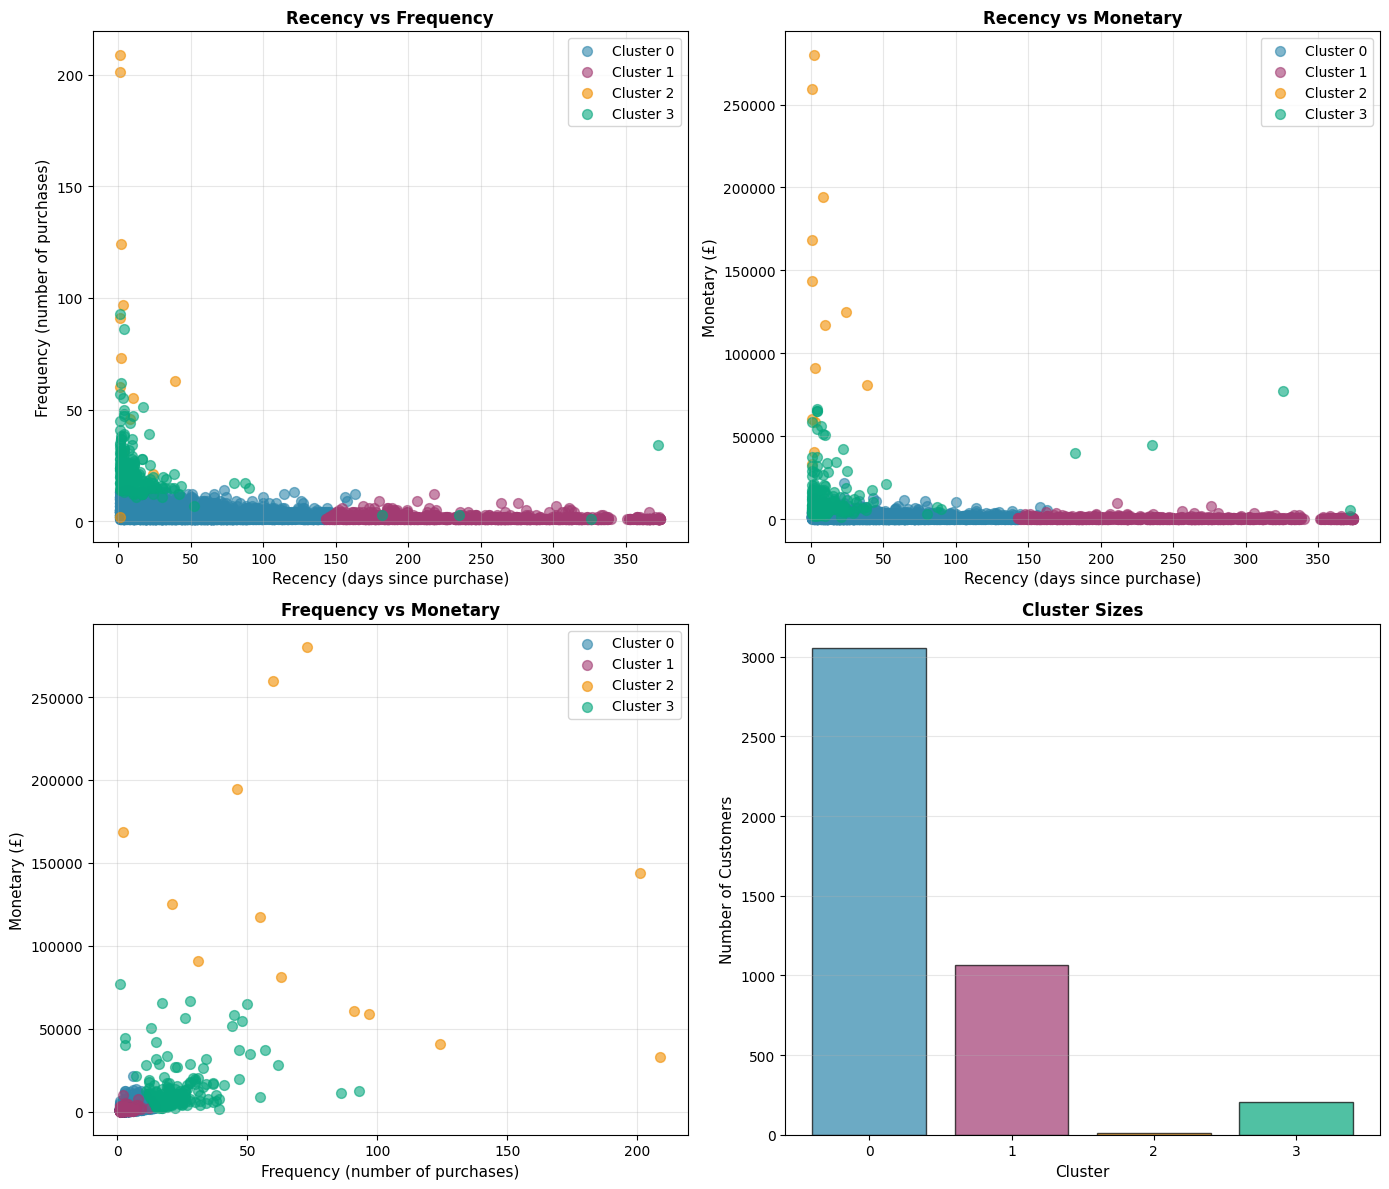

Visualization complete!


In [49]:
# Create scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']

# Plot 1: Recency vs Frequency
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[0, 0].scatter(cluster_data['Recency'], cluster_data['Frequency'], 
                      label=f'Cluster {cluster}', alpha=0.6, s=50, color=colors[cluster])
axes[0, 0].set_xlabel('Recency (days since purchase)', fontsize=11)
axes[0, 0].set_ylabel('Frequency (number of purchases)', fontsize=11)
axes[0, 0].set_title('Recency vs Frequency', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Recency vs Monetary
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[0, 1].scatter(cluster_data['Recency'], cluster_data['Monetary'], 
                      label=f'Cluster {cluster}', alpha=0.6, s=50, color=colors[cluster])
axes[0, 1].set_xlabel('Recency (days since purchase)', fontsize=11)
axes[0, 1].set_ylabel('Monetary (£)', fontsize=11)
axes[0, 1].set_title('Recency vs Monetary', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Frequency vs Monetary
for cluster in range(4):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    axes[1, 0].scatter(cluster_data['Frequency'], cluster_data['Monetary'], 
                      label=f'Cluster {cluster}', alpha=0.6, s=50, color=colors[cluster])
axes[1, 0].set_xlabel('Frequency (number of purchases)', fontsize=11)
axes[1, 0].set_ylabel('Monetary (£)', fontsize=11)
axes[1, 0].set_title('Frequency vs Monetary', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster sizes
cluster_sizes = rfm['Cluster'].value_counts().sort_index()
axes[1, 1].bar(range(4), cluster_sizes.values, color=colors, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Cluster', fontsize=11)
axes[1, 1].set_ylabel('Number of Customers', fontsize=11)
axes[1, 1].set_title('Cluster Sizes', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(4))
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Visualization complete!')

## Step 9: Save Results

In [50]:
# Save the segmented data
rfm.to_csv('customer_segments.csv')

print('Customer segments saved to customer_segments.csv')
print(f'\nDataset shape: {rfm.shape}')
print(f'Columns: {rfm.columns.tolist()}')


Customer segments saved to customer_segments.csv

Dataset shape: (4338, 8)
Columns: ['Recency', 'Frequency', 'Monetary', 'AOV', 'CLV', 'Days_as_Customer', 'Purchase_Rate', 'Cluster']
